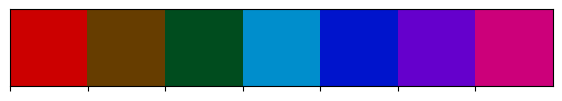

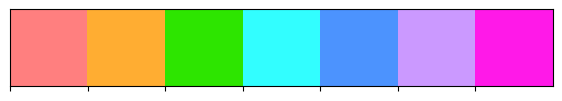

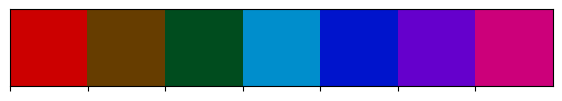

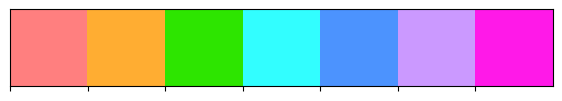

In [1]:
import os
import sys
import torch
import numpy as np
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt
import time
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.wrappers.env_wrappers import WallObs, WindowViewObs, ObsToImage, MultiChannel
from src.wrappers.monitor_wrappers import RoomMonitor

from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()

In [2]:
device = "mps:0"
grid_size = [10, 10]
eps_decay = 0.0001
n_mdp_actions = 6
window_size = 11
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
timesteps_freq = int(5e5)
n_rows, n_colums = grid_size

In [10]:
def select_action(q_values) -> int:
    """Choose an action from a Q value distribution/ break ties to a random action"""
    indices = np.argwhere(q_values == np.max(q_values))
    return random.choice(indices)[0]

def load_train_reward(dir: str):
    reward_train_all = np.load(dir + "reward_train_all.npy", allow_pickle=True)[()]["seeds_y_axis"]
    reward_train_mean = np.load(dir + "reward_train_mean.npy")
    reward_train_std = np.load(dir + "reward_train_std.npy")
    reward_train_confidence = np.load(dir + "reward_train_confidence.npy")
    return reward_train_all, reward_train_mean, reward_train_std, reward_train_confidence

def confidence_interval(data, confidence=0.95):
    conf = scipy.stats.sem(data) * scipy.stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return conf

def confidence_interval_2d(data: np.ndarray, confidence: float=0.95):
    confds = []
    for j in range(data.shape[1]):
        k = confidence_interval(data[:, j], confidence)
        confds.append(k)
    return np.array(confds)

def bootstrap_ci(data, stat_function=np.mean, n_bootstrap=1000, ci=95):
    """
    Computes the bootstrap confidence interval for a given statistic.
    
    Parameters:
        data (array-like): Sample data.
        stat_function (function): Function to compute the statistic (default: np.mean).
        n_bootstrap (int): Number of bootstrap resamples (default: 1000).
        ci (float): Confidence level (default: 95 for a 95% confidence interval).
    
    Returns:
        tuple: Lower and upper bound of the confidence interval.
    """
    boot_samples = np.random.choice(data, (n_bootstrap, len(data)), replace=True)
    boot_stats = np.apply_along_axis(stat_function, 1, boot_samples)
    
    lower_percentile = (100 - ci) / 2
    upper_percentile = 100 - lower_percentile
    
    lower_bound = np.percentile(boot_stats, lower_percentile)
    upper_bound = np.percentile(boot_stats, upper_percentile)
    
    return np.array([lower_bound, upper_bound])

In [4]:
env = gym.make("gym_monitor/Plants-Watering-v1",
    grid_size=grid_size,
    n_plants=8,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode = "human",
    add_new_plants=False,
    add_more_plants=True,
    )

env = WallObs(env, grid_size=grid_size, n_walls=5)
env = WindowViewObs(env, window_size=window_size)
env = MultiChannel(env)
env = RoomMonitor(env, full_monitor=False, monitor_cost=0.0, monitor_column_ind=5)

/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:29: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float64. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:34: UserWarning: WARN: It seems a Box observation space is an image but the lower and upper bounds are not [0, 255]. Actual lower bound: 0.0, upper bound: 1.0. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
  logger.warn(


In [4]:
ep_max_length = 100
n_seeds = 30
timestep_clip = 5e6

discount = np.array([gamma**i for i in range(ep_max_length)])
# main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/3_room/window_{}/eps_decay_0.0001/".format(
#     n_rows, n_colums, dryness, window_size)
log_dir = "../general_models/Plants/reward_model/10_10_channel/dry_0.05/3_room/window_11/eps_decay_1e-07/q_lr_0.0001/reward_lr_0.0001"
cut_indx = 5 if n_rows == 10 else 3
cut_indx_1 = int(cut_indx * 2)

In [21]:
# k = 10
n = 10
n_ep = 1000
n_seeds = 10

for k in [1, 5]:
    stasistic = {
        "w_dry_plant_1" : np.zeros((n_seeds, n_ep)),
        "w_dry_plant_2" : np.zeros((n_seeds, n_ep)),
        "w_dry_cacti_1" : np.zeros((n_seeds, n_ep)),
        "w_dry_cacti_2" : np.zeros((n_seeds, n_ep)),
        "w_wet_plant": np.zeros((n_seeds, n_ep)),
        "w_wet_cacti": np.zeros((n_seeds, n_ep)),
        "w_diff_1": np.zeros((n_seeds, n_ep)),
        "w_diff_2": np.zeros((n_seeds, n_ep)),
        "w_diff_3": np.zeros((n_seeds, n_ep)),
        "w_diff_4": np.zeros((n_seeds, n_ep)),
        "w_diff_5": np.zeros((n_seeds, n_ep)),
        "w_floor": np.zeros((n_seeds, n_ep)),
    }
    for seed in range(n_seeds):
        # q_model = torch.load(log_dir + "/q_network_{}_of_{}".format(k, n), map_location=torch.device(device), weights_only=False)
        q_model = torch.load(log_dir + "/{}_of_{}/q_network_{}".format(k, n, seed + 20), map_location=torch.device(device), weights_only=False)
        for episode in range(n_ep):
            floor, dry_cacti_1, dry_cacti_2, dry_plant_1, dry_plant_2, wet_plant, wet_cacti = 0, 0, 0, 0, 0, 0, 0
            diff_1, diff_2, diff_3, diff_4, diff_5 = 0, 0, 0, 0, 0
            s, _ = env.reset()
            total_r, timestep = 0, 0
            done = False
            # env.render()
            while timestep < 100 and not done:
                mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)
                mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=device).unsqueeze(0)
                
                with torch.no_grad():
                    q_values = q_model[5:](torch.concat((q_model[:5](mdp_obs), mon_obs), 1))
                action = select_action(q_values.cpu().numpy().squeeze())
                agent_pos =  env.get_agent_pos()
                plant = env.get_grid()[1, agent_pos[0], agent_pos[1]]
                dryness_level = s["mdp"][4, window_size // 2, window_size // 2]
                s, r, done, _, info = env.step({"mdp": action, "monitor": 0})
                if action == 4:
                    if plant == 0.0:  # spill water in the floor
                        floor += 1
                    elif plant == 0.5: # water cactus
                        if dryness_level == 0:
                            wet_cacti += 1
                        else:
                            if agent_pos[1] < 5:
                                dry_cacti_1 += 1
                            else:
                                dry_cacti_2 += 1
                    elif plant == 1.0: # water Plant
                        if dryness_level == 0:
                            wet_plant += 1
                        else:
                            if agent_pos[1] < 5:
                                dry_plant_1 += 1
                            else:
                                dry_plant_2 += 1
                    elif plant == 0.125: # water diff 1
                        diff_1 += 1
                    elif plant == 0.25: # water diff 2
                        diff_2 += 1
                    elif plant == 0.375: # water diff 3
                        diff_3 += 1
                    elif plant == 0.625: # water diff 4
                        diff_4 += 1
                    else:
                    # elif plant == 0.875: # water diff 5
                        diff_5 += 1
                reward = info["mdp_reward"] + r["monitor"]
                total_r += reward * (gamma**timestep)
                timestep += 1
                # env.render()
            stasistic["w_dry_plant_1"][seed, episode] = dry_plant_1
            stasistic["w_dry_plant_2"][seed, episode] = dry_plant_2
            stasistic["w_dry_cacti_1"][seed, episode] = dry_cacti_1
            stasistic["w_dry_cacti_2"][seed, episode] = dry_cacti_2
            stasistic["w_wet_plant"][seed, episode] = wet_plant
            stasistic["w_wet_cacti"][seed, episode] = wet_cacti
            stasistic["w_diff_1"][seed, episode] = diff_1
            stasistic["w_diff_2"][seed, episode] = diff_2
            stasistic["w_diff_3"][seed, episode] = diff_3
            stasistic["w_diff_4"][seed, episode] = diff_4
            stasistic["w_diff_5"][seed, episode] = diff_5
            stasistic["w_floor"][seed, episode] = floor
    # env.close()
    np.save(log_dir + "/{}_of_{}/stasistic_2.npy".format(k, n), stasistic)

In [23]:
# n = 10
# for k in [1, 5, 10]:
#     stat = np.load(log_dir + "/{}_of_{}/stasistic.npy".format(k, n), allow_pickle=True)[()]
#     stat_1 = np.load(log_dir + "/{}_of_{}/stasistic_1.npy".format(k, n), allow_pickle=True)[()]
#     stat_2 = np.load(log_dir + "/{}_of_{}/stasistic_2.npy".format(k, n), allow_pickle=True)[()]
#     all_stat = {}
#     for key in stat:
#         all_stat.update({key: np.concatenate((stat[key], stat_1[key], stat_2[key]), 0)})
#         np.save(log_dir + "/{}_of_{}/stasistic_all.npy".format(k, n), all_stat)

In [7]:
n_plants = {"w_diff_1": 0.8, "w_diff_2": 0.8, "w_diff_3": 0.8, "w_diff_4": 0.8, "w_diff_5": 0.8,
            "w_dry_plant_1": 4, "w_dry_plant_2": 4, "w_dry_cacti_1": 4, "w_dry_cacti_2": 4, "w_floor": 80}

k_list = [10, 5, 1,]
n_list = [10, 10, 10,]
to_plot = {
    "w_diff_1": [0, 0, 1], "w_diff_2": [0, 1, 0], "w_diff_3": [1, 0, 0], "w_diff_4": [1, 0, 1], "w_diff_5": [1, 1, 1],
    # "w_diff_1": [0, 0, 1], "w_diff_2": [0, 1, 0], "w_diff_4": [1, 0, 1],
    "w_dry_plant_1": "Plant Zone 1", "w_dry_plant_2": "Plant Zone 2",
    # "w_dry_cacti_1": "Cactus Zone 1", "w_dry_cacti_2": "Cactus Zone 2", "w_floor": "Floor",
}

x_labels = []
means, conf = np.zeros((len(k_list), len(to_plot))), np.zeros((len(k_list), len(to_plot)))
seeds_means = np.zeros((len(k_list), len(to_plot), n_seeds))
count = 0

for i in range(len(k_list)):
    k, n = k_list[i], n_list[i]
    x_labels.append("{}-of-{}".format(k, n))
    stat = np.load(log_dir + "/{}_of_{}/stasistic_all.npy".format(k, n), allow_pickle=True)[()]
    count = 0
    for key in to_plot:
        if key in ["w_dry_plant_1", "w_dry_plant_2"]:
            means[i, count] = np.mean(stat[key].reshape(-1)) / 1
        else:
            means[i, count] = np.mean(stat[key].reshape(-1)) / 1
        seeds_means[i, count] = np.mean(stat[key], 1)
        # means[i, count] = np.mean(stat[key].reshape(-1)) / n_plants[key]
        # conf[i, count] = confidence_interval(stat[key].reshape(-1))
        if key in ["w_dry_plant_1", "w_dry_plant_2"]:
            conf[i, count] = confidence_interval(np.mean(stat[key], 1) / 1)
        else:
            conf[i, count] = confidence_interval(np.mean(stat[key], 1) / 1)
        # conf[i, count] = confidence_interval(np.mean(stat[key], 1) / n_plants[key])
        count += 1

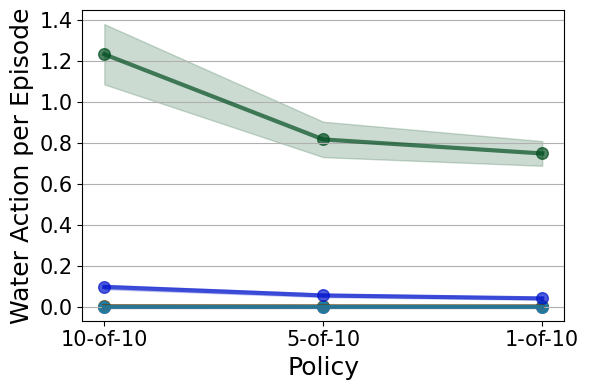

In [48]:
fig = plt.figure(figsize=(6, 4))
for key in range(len(to_plot)):
    plt.plot(np.arange(len(k_list)), means[:, key], lw=3,  c=dark_colors[key], alpha=0.7, label=to_plot[list(to_plot.keys())[key]])
    plt.scatter(np.arange(len(k_list)), means[:, key], marker="o", s=70,  color=dark_colors[key], alpha=0.7)
    plt.fill_between(np.arange(len(k_list)), means[:, key] - conf[:, key], means[:, key] + conf[:, key], color=dark_colors[key], alpha=0.2)

plt.yticks(fontsize=15)
plt.xticks(np.arange(len(k_list)), x_labels, fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.xlabel(r"Policy", fontsize=18)
plt.ylabel("Water Action per Episode", fontsize=18)
plt.tight_layout()
# fig.savefig(log_dir + "/frequency_all_plants_no_legend.pdf", dpi=300,)

## All Novel Plants

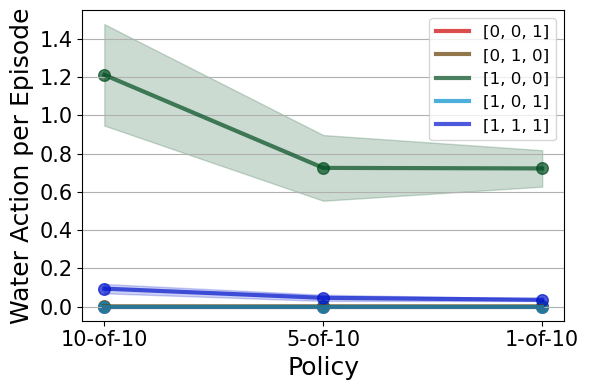

## All Novel Plants + plants 

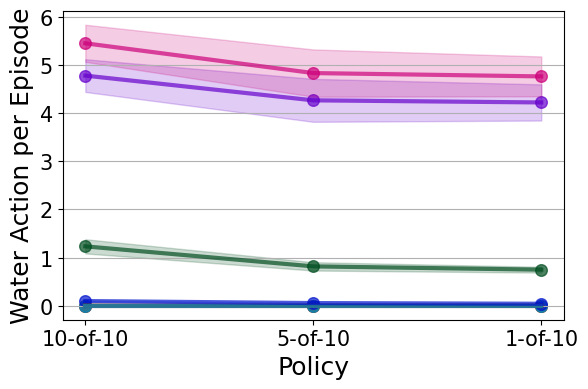

In [50]:
fig = plt.figure(figsize=(6, 4))
for key in range(len(to_plot)):
    plt.plot(np.arange(len(k_list)), means[:, key], lw=3,  c=dark_colors[key], alpha=0.7, label=to_plot[list(to_plot.keys())[key]])
    plt.scatter(np.arange(len(k_list)), means[:, key], marker="o", s=70,  color=dark_colors[key], alpha=0.7)
    plt.fill_between(np.arange(len(k_list)), means[:, key] - conf[:, key], means[:, key] + conf[:, key], color=dark_colors[key], alpha=0.2)

plt.yticks(fontsize=15)
plt.xticks(np.arange(len(k_list)), x_labels, fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.xlabel(r"Policy", fontsize=18)
plt.ylabel("Water Action per Episode", fontsize=18)
plt.tight_layout()
# fig.savefig(log_dir + "/frequency_all_novel_plants_no_legend.pdf", dpi=300,)

## All Novel Plants + plants Normalized

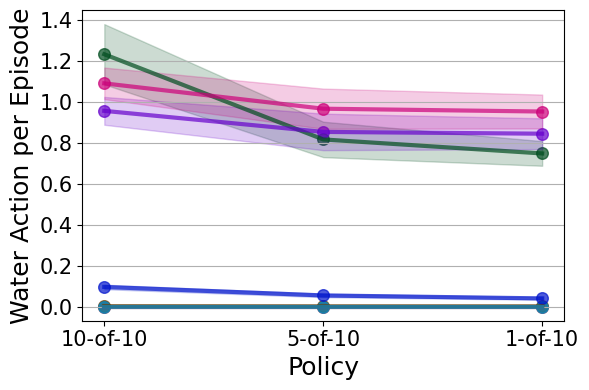

In [52]:
fig = plt.figure(figsize=(6, 4))
for key in range(len(to_plot)):
    plt.plot(np.arange(len(k_list)), means[:, key], lw=3,  c=dark_colors[key], alpha=0.7, label=to_plot[list(to_plot.keys())[key]])
    plt.scatter(np.arange(len(k_list)), means[:, key], marker="o", s=70,  color=dark_colors[key], alpha=0.7)
    plt.fill_between(np.arange(len(k_list)), means[:, key] - conf[:, key], means[:, key] + conf[:, key], color=dark_colors[key], alpha=0.2)

plt.yticks(fontsize=15)
plt.xticks(np.arange(len(k_list)), x_labels, fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)
plt.xlabel(r"Policy", fontsize=18)
plt.ylabel("Water Action per Episode", fontsize=18)
plt.tight_layout()
# fig.savefig(log_dir + "/frequency_all_novel_plants_normal_no_legend.pdf", dpi=300,)

## Table frequency

|Plant | $10$-of-$10$ | $5$-of-$10$ frequency | $1$-of-$10$ frequency |
| -- | -- | -- | --|
|Plants Zone 1| $4.95\pm 0.68$| $3.84\pm 0.90$| $4.18\pm 0.057$|
|Plants Zone 2| $5.42\pm 0.77$| $4.35\pm1.03$| $4.69\pm 0.66$|
|[0, 0, 1]| $0.00 \pm 0.00$| $0.00 \pm 0.00$ |  $0.00 \pm 0.00$|
|[0, 1, 0]| $0.00 \pm 0.00$| $0.00 \pm 0.00$ | $0.00 \pm 0.00$ |
|[1, 0, 0]| $1.21\pm 0.27$| $0.73\pm 0.17$| $0.72\pm 0.10$|
|[1, 0, 1]| $0.00 \pm 0.00$| $0.00 \pm 0.00$ | $0.00 \pm 0.00$|
|[1, 1, 1]| $0.09\pm 0.02$| $0.05\pm 0.02$ | $0.04\pm 0.01$|

## Table Reduction (10 seeds)

|Plant | $10$-of-$10$ | $5$-of-$10$ reduction($\times$) | $1$-of-$10$ reduction($\times$)|
| -- | -- | -- | --|
|Plants Zone 1| $4.95\pm 0.68$| $1.29\times \pm 0.30$| $1.18\times \pm 0.24$|
|Plants Zone 2| $5.42\pm 0.77$| $1.25\times \pm 0.30$| $1.15\times \pm 0.25$|
|[0, 0, 1]| $0.00 \pm 0.00$| $0.00 \pm 0.00$ |  $0.00 \pm 0.00$|
|[0, 1, 0]| $0.00 \pm 0.00$| $0.00 \pm 0.00$ | $0.00 \pm 0.00$ |
|[1, 0, 0]| $1.21\pm 0.27$| $1.67\times \pm 0.41$| $1.68\times \pm 0.52$|
|[1, 0, 1]| $0.00 \pm 0.00$| $0.00 \pm 0.00$ | $0.00 \pm 0.00$|
|[1, 1, 1]| $0.09\pm 0.02$| $2.05\times 0.71$| $2.64\times \pm 1.04$|

## Table Reduction (30 seeds)

|Plant | Reward Model | $10$-of-$10$ | $5$-of-$10$ reduction($\times$) | $1$-of-$10$ reduction($\times$)|
| -- | -- | -- | -- | --|
|Plants Zone 1| $3.28\pm 0.29$ | $4.87\pm 0.34$| $1.12\times \pm 0.20$| $1.13\times \pm 0.23$|
|Plants Zone 2| $4.13\pm 0.36$ | $5.45\pm 0.39$| $1.13\times \pm 0.19$| $1.14\times \pm 0.21$|
|[0, 0, 1]| $0.00 \pm 0.00$ | $0.00 \pm 0.00$| $0.00 \pm 0.00$ |  $0.00 \pm 0.00$|
|[0, 1, 0]| $0.01 \pm 0.00$ | $0.00 \pm 0.00$| $0.00 \pm 0.00$ | $0.00 \pm 0.00$ |
|[1, 0, 0]| $4.01\pm 3.75$ | $1.23\pm 0.15$| $1.51\times \pm 0.28$| $1.65\times \pm 0.28$|
|[1, 0, 1]|  $0.00 \pm 0.00$ | $0.00 \pm 0.00$| $0.00 \pm 0.00$ | $0.00 \pm 0.00$|
|[1, 1, 1]|  $0.10\pm 0.05$ | $0.10\pm 0.01$| $1.76\times 0.34$| $2.40\times \pm 0.63$|

In [63]:
l = 6
# np.round(means[0, l] / means[2, l], 2)
round(confidence_interval(seeds_means[0, l] / seeds_means[2, l]), 2)

0.21

In [33]:
np.round(means[0], 2), np.round(conf[0], 2)

(array([0.  , 0.  , 1.23, 0.  , 0.1 , 4.78, 5.45]),
 array([0.  , 0.  , 0.15, 0.  , 0.01, 0.34, 0.39]))

In [16]:
1.67 -(1.21 / np.array([0.73 - 0.17, 0.73 + 0.17]))

array([-0.49071429,  0.32555556])

In [6]:
np.round(means[0, 4] / means[1, 4], 2) , np.round(conf[0, 4] / conf[1, 4], 2)

(2.05, 1.5)

In [7]:
round(confidence_interval(seeds_means[0, 6] / seeds_means[1, 6]), 2)

0.30272061458058747

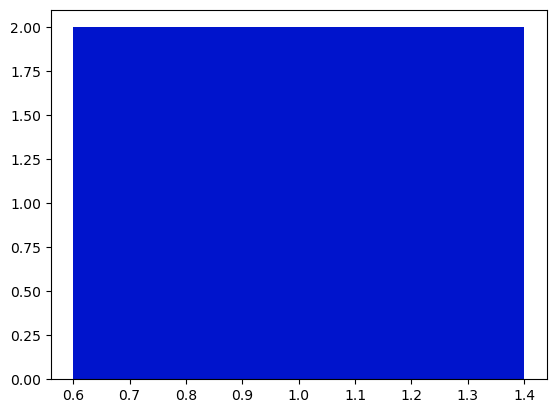

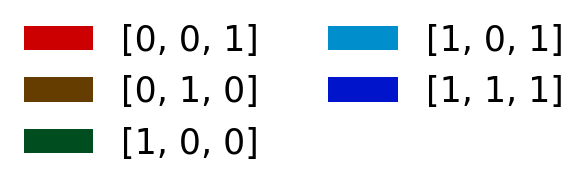

In [15]:
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", dark_colors[i]) for i in range(5)]
fig = plt.figure(figsize=(5.5, 1.6))
fig.legend(handles, to_plot.values(), fontsize=25, ncol=2, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig(log_dir + "/legend.pdf", dpi=300,)

## confidence interval

In [5]:
stat_10_10 = np.load(log_dir + "/10_of_10/stasistic_all.npy", allow_pickle=True)[()]
stat_5_10 = np.load(log_dir + "/5_of_10/stasistic_all.npy", allow_pickle=True)[()]
stat_1_10 = np.load(log_dir + "/1_of_10/stasistic_all.npy", allow_pickle=True)[()]
stat_reward = np.load(log_dir + "/stasistic_all.npy", allow_pickle=True)[()]

In [8]:
n_seeds = 30
mean_reward = np.zeros((len(to_plot), n_seeds))
mean_10_10 = np.zeros((len(to_plot), n_seeds))
mean_1_10 = np.zeros((len(to_plot), n_seeds))
mean_5_10 = np.zeros((len(to_plot), n_seeds))
for i, key in enumerate(to_plot):
    mean_reward[i] = np.mean(stat_reward[key], 1)
    mean_1_10[i] = np.mean(stat_1_10[key], 1)
    mean_10_10[i] = np.mean(stat_10_10[key], 1)
    mean_5_10[i] = np.mean(stat_5_10[key], 1)

### Mean & interval confidance for each policy

In [11]:
for indx in range(7):
    print(np.round(np.mean(mean_1_10[indx]), 2), np.round(bootstrap_ci(mean_1_10[indx]), 2))

0.0 [0. 0.]
0.0 [0. 0.]
0.75 [0.69 0.8 ]
0.0 [0. 0.]
0.04 [0.03 0.05]
4.22 [3.86 4.56]
4.77 [4.36 5.15]


### Ratio over Mean

In [12]:
for indx in range(7):
    mean_matrix = np.mean(mean_1_10[indx]) / np.mean(mean_reward[indx]) 
    conf_matrix = bootstrap_ci(mean_1_10[indx], ci=np.sqrt(95)) / bootstrap_ci(mean_reward[indx], ci=np.sqrt(95))
    print(np.round(mean_matrix, 2), np.round(conf_matrix, 2))

nan [nan nan]
0.25 [0.26 0.26]
0.19 [0.19 0.19]
0.0 [0. 0.]
0.41 [0.43 0.41]
1.29 [1.29 1.29]
1.16 [1.16 1.16]


/var/folders/wr/tm6dhxps7gnfznj02g89rcx40000gn/T/ipykernel_17165/2417459380.py:2: RuntimeWarning: invalid value encountered in scalar divide
  mean_matrix = np.mean(mean_1_10[indx]) / np.mean(mean_reward[indx])
/var/folders/wr/tm6dhxps7gnfznj02g89rcx40000gn/T/ipykernel_17165/2417459380.py:3: RuntimeWarning: invalid value encountered in divide
  conf_matrix = bootstrap_ci(mean_1_10[indx], ci=np.sqrt(95)) / bootstrap_ci(mean_reward[indx], ci=np.sqrt(95))


### Mean over ratio

In [30]:
def filter_ratio(a, b):
    """
    filter a/b
    zero/zero --> 1
    int/zero --> zero
    """
    assert len(a) == len(b)
    fliter_ratio = np.zeros(len(a))
    for i in range(len(a)):
        if b[i] == 0:
            if a[i] == 0:
                fliter_ratio[i] = 1
            else:
                fliter_ratio[i] = 1
        else:
                fliter_ratio[i] = a[i]/b[i]
    return fliter_ratio

In [31]:
for indx in range(7):
    ma = filter_ratio(mean_1_10[indx] , mean_reward[indx])
    print(np.round(np.mean(ma), 2), np.round(bootstrap_ci(ma), 2))

1.0 [1. 1.]
0.75 [0.47 1.02]
1.02 [0.8  1.28]
0.97 [0.9 1. ]
3.27 [1.89 4.92]
1.41 [1.21 1.68]
1.27 [1.08 1.52]


In [ ]:
for indx in range(7):
    mean_matrix = np.mean(mean_1_10[indx] / mean_reward[indx]) 
    conf_matrix = bootstrap_ci(mean_1_10[indx], ci=np.sqrt(95)) / bootstrap_ci(mean_reward[indx], ci=np.sqrt(95))
    print(np.round(mean_matrix, 2), np.round(conf_matrix, 2))

In [84]:
np.round(np.mean(mean_5_10, 1) / np.mean(mean_reward, 1), 2)

/var/folders/wr/tm6dhxps7gnfznj02g89rcx40000gn/T/ipykernel_2307/1558548667.py:1: RuntimeWarning: invalid value encountered in divide
  np.round(np.mean(mean_1_10, 1) / np.mean(mean_reward, 1), 2)


array([ nan, 0.25, 0.19, 0.  , 0.41, 1.29, 1.16])

In [67]:
key = "w_dry_plant_1"
n_samples = stat_1_10[key].reshape(-1).shape[0]
n_itr = int(3e4)
conf_10_10, conf_5_10, conf_1_10 = np.zeros(n_itr), np.zeros(n_itr), np.zeros(n_itr)
for j in range(n_itr):
    samples = np.random.choice(np.arange(n_samples), 1, replace=True)
    conf_10_10[j] = np.sum(stat_10_10[key].reshape(-1)[samples])
    conf_5_10[j] = np.sum(stat_5_10[key].reshape(-1)[samples])
    conf_1_10[j] = np.sum(stat_1_10[key].reshape(-1)[samples])

In [91]:
mian_list = np.arange(10)
np.random.choice(mian_list, 10, replace=True)

array([7, 3, 6, 3, 0, 5, 5, 9, 5, 0])

In [105]:
indx = 1
np.round(bootstrap_ci(mean_reward[1]), 2)

array([0.  , 0.01])

In [113]:
non_zero_indx = np.argwhere(mean_reward[indx] != 0)[:, 0]
np.mean(mean_5_10[indx, non_zero_indx] / mean_reward[indx, non_zero_indx])

0.7356735856735857

In [114]:
mean_5_10[indx, non_zero_indx] , mean_reward[indx, non_zero_indx]

(array([0.001, 0.   , 0.004, 0.003, 0.   , 0.002, 0.001, 0.001, 0.001,
        0.001, 0.001, 0.001, 0.002, 0.002, 0.   , 0.001, 0.001, 0.003,
        0.001, 0.002, 0.   , 0.005, 0.001, 0.005, 0.002, 0.003]),
 array([0.003, 0.004, 0.007, 0.01 , 0.004, 0.007, 0.002, 0.01 , 0.001,
        0.002, 0.001, 0.001, 0.003, 0.054, 0.009, 0.018, 0.009, 0.012,
        0.004, 0.001, 0.003, 0.002, 0.006, 0.002, 0.001, 0.001]))